<a href="https://colab.research.google.com/github/josedmaldonado-r/Distribucion-y-Probabilidad/blob/main/APE03_Jose_Maldonado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Práctica de Laboratorio Nro. 004: Variables Aleatorias Discretas y Continuas**

###**Asignatura:** Teoría de la Distribución y Probabilidad  
###**Ciclo:** Segundo Ciclo "A"  
###**Realizado por:** Jose Maldonado   
###**Institución:** Universidad Nacional de Loja  
###**Fecha:** 02 de mayo de 2026

---

## 1. Introducción
En esta práctica se explora la naturaleza del azar mediante la modelación computacional. Utilizaremos el ecosistema de ciencia de datos de Python para diferenciar empíricamente entre variables discretas (lanzamiento de dados) y continuas (tiempos de respuesta de servidores).

## 2. Objetivos de Aprendizaje
* Diferenciar entre variables aleatorias discretas y continuas.
* Interpretar y construir funciones de masa de probabilidad (PMF) y funciones de densidad (PDF).
* Calcular probabilidades acumuladas usando la función de distribución acumulada (CDF).

## **Tarea 1: Configuracion del Entorno**
1.	Abra Jupyter Notebook o Google Colab.
2.	Importe las librerias necesarias:



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint, norm, binom, uniform
import seaborn as sns

# Configuracion de estilo
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

print("Entorno configurado correctamente")


Entorno configurado correctamente


## **Tarea 2: Variable Aleatoria Discreta - Lanzamiento de Dado**
**Caso:** X = resultado del lanzamiento de un dado justo.
2.	Defina la variable aleatoria y su PMF:


In [ ]:
# Variable aleatoria: resultado de un dado
# X puede tomar valores: 1, 2, 3, 4, 5, 6

# Valores posibles
x_valores = np.array([1, 2, 3, 4, 5, 6])

# PMF: cada valor tiene probabilidad 1/6
pmf_dado = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])

print("Valores de X:", x_valores)
print("PMF p(x):", pmf_dado)
print("Suma de probabilidades:", np.sum(pmf_dado))


Valores de X: [1 2 3 4 5 6]
PMF p(x): [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
Suma de probabilidades: 0.9999999999999999


3.	Visualice la PMF:

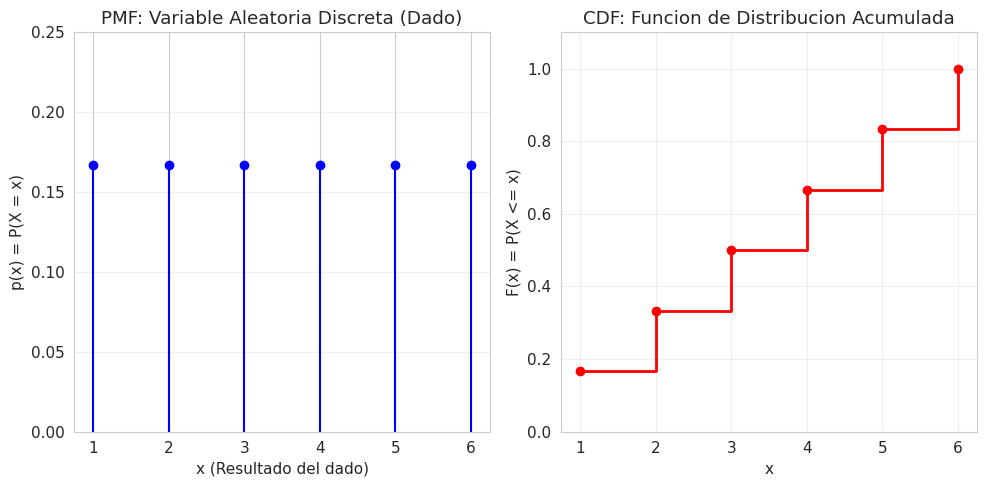

In [ ]:
# Visualizacion de la PMF
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.xlabel('x (Resultado del dado)')
plt.ylabel('p(x) = P(X = x)')
plt.title('PMF: Variable Aleatoria Discreta (Dado)')
plt.xticks(x_valores)
plt.ylim(0, 0.25)
plt.grid(axis='y', alpha=0.3)

# CDF
cdf_dado = np.cumsum(pmf_dado)
plt.subplot(1, 2, 2)
plt.step(x_valores, cdf_dado, where='post', color='red', linewidth=2)
plt.scatter(x_valores, cdf_dado, color='red', zorder=5)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Funcion de Distribucion Acumulada')
plt.xticks(x_valores)
plt.ylim(0, 1.1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



4.	Calcule probabilidades especificas:

In [ ]:
# a) P(X = 4)
prob_4 = pmf_dado[x_valores == 4][0]
print(f"P(X = 4) = {prob_4:.4f}")

# b) P(X <= 3) usando CDF
prob_menor_3 = cdf_dado[x_valores == 3][0]
print(f"P(X <= 3) = {prob_menor_3:.4f}")

# c) P(2 <= X <= 5)
prob_entre_2_5 = cdf_dado[x_valores == 5][0] - cdf_dado[x_valores == 1][0]
print(f"P(2 <= X <= 5) = {prob_entre_2_5:.4f}")


P(X = 4) = 0.1667
P(X <= 3) = 0.5000
P(2 <= X <= 5) = 0.6667


## **Tarea 3: Variable Aleatoria Continua - Distribucion Normal**
**Caso:** X = tiempo de respuesta de un servidor (ms), distribuido normalmente con mu = 200 y sigma = 30.

1.	Defina la distribucion y visualice la PDF:


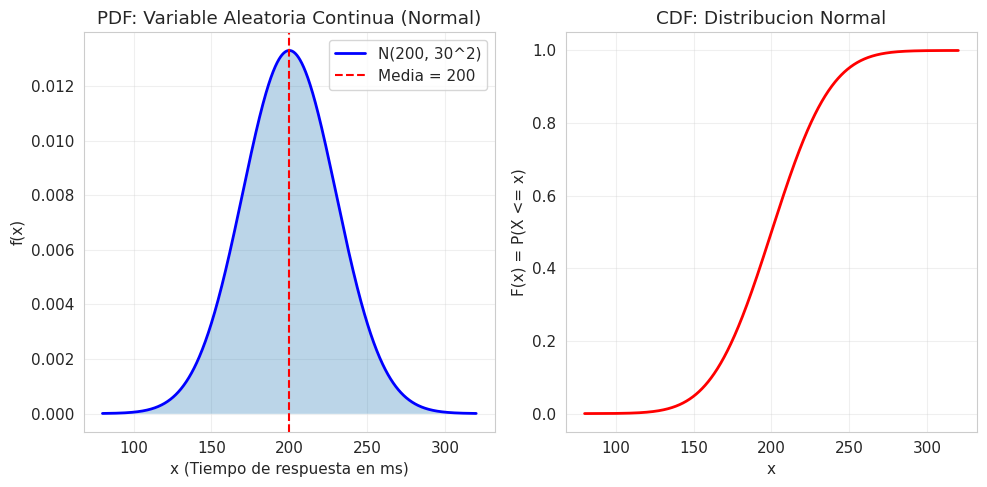

In [ ]:
# Parametros de la distribucion normal
mu = 200  # media
sigma = 30  # desviacion estandar

# Crear la distribucion
dist_normal = norm(loc=mu, scale=sigma)

# Rango de valores para graficar
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# PDF
pdf_normal = dist_normal.pdf(x)

# Visualizacion
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x, pdf_normal, 'b-', linewidth=2, label=f'N({mu}, {sigma}^2)')
plt.fill_between(x, pdf_normal, alpha=0.3)
plt.axvline(mu, color='red', linestyle='--', label=f'Media = {mu}')
plt.xlabel('x (Tiempo de respuesta en ms)')
plt.ylabel('f(x)')
plt.title('PDF: Variable Aleatoria Continua (Normal)')
plt.legend()
plt.grid(alpha=0.3)

# CDF
cdf_normal = dist_normal.cdf(x)
plt.subplot(1, 2, 2)
plt.plot(x, cdf_normal, 'r-', linewidth=2)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Distribucion Normal')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


2.	Calcule probabilidades:

In [ ]:
# a) P(X <= 180)
prob_menor_180 = dist_normal.cdf(180)
print(f"P(X <= 180) = {prob_menor_180:.4f} ({prob_menor_180*100:.2f}%)")

# b) P(X > 250)
prob_mayor_250 = 1 - dist_normal.cdf(250)
print(f"P(X > 250) = {prob_mayor_250:.4f} ({prob_mayor_250*100:.2f}%)")

# c) P(170 <= X <= 230)
prob_entre = dist_normal.cdf(230) - dist_normal.cdf(170)
print(f"P(170 <= X <= 230) = {prob_entre:.4f} ({prob_entre*100:.2f}%)")

# d) Percentil 95
p95 = dist_normal.ppf(0.95)
print(f"\nPercentil 95: {p95:.2f} ms")
print(f"El 95% de los tiempos de respuesta son menores a {p95:.2f} ms")


P(X <= 180) = 0.2525 (25.25%)
P(X > 250) = 0.0478 (4.78%)
P(170 <= X <= 230) = 0.6827 (68.27%)

Percentil 95: 249.35 ms
El 95% de los tiempos de respuesta son menores a 249.35 ms


## **Tarea 4: Comparacion Visual PMF vs PDF**

1.	Cree una visualizacion comparativa:


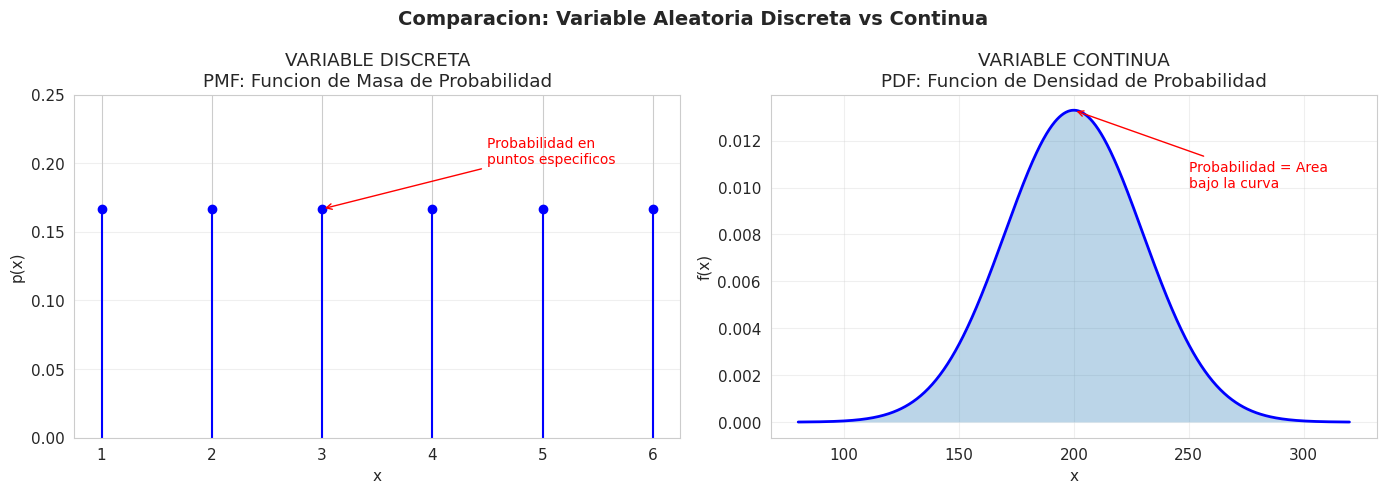

In [ ]:
# Comparacion PMF vs PDF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variable Discreta (Dado)
axes[0].stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
axes[0].set_xlabel('x')
axes[0].set_ylabel('p(x)')
axes[0].set_title('VARIABLE DISCRETA\nPMF: Funcion de Masa de Probabilidad')
axes[0].set_xticks(x_valores)
axes[0].set_ylim(0, 0.25)
axes[0].grid(axis='y', alpha=0.3)

# Anotaciones
axes[0].annotate('Probabilidad en\npuntos especificos', xy=(3, 1/6), xytext=(4.5, 0.2),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

# Variable Continua (Normal)
axes[1].plot(x, pdf_normal, 'b-', linewidth=2)
axes[1].fill_between(x, pdf_normal, alpha=0.3)
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_title('VARIABLE CONTINUA\nPDF: Funcion de Densidad de Probabilidad')
axes[1].grid(alpha=0.3)

# Anotaciones
axes[1].annotate('Probabilidad = Area\nbajo la curva', xy=(200, norm.pdf(200, 200, 30)), xytext=(250, 0.01),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

plt.suptitle('Comparacion: Variable Aleatoria Discreta vs Continua', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## **Tarea 5: Aplicacion - Variables Aleatorias en la UNL**

***1.	En su grupo, identifique 5 variables aleatorias en diferentes areas de la UNL:***

•	Biblioteca: _________________________________________________

•	Cafeteria: _________________________________________________

•	Laboratorios: ______________________________________________

•	Estacionamiento: ___________________________________________

•	Aulas de clase: ____________________________________________

***2.	Para cada variable, determine:***

•	Tipo: Discreta / Continua

•	Posibles valores que puede tomar

•	Distribucion de probabilidad esperada (si se puede inferir)

***10.	Complete la tabla de registro:***


In [ ]:
import pandas as pd

# 1. Configuración para separar y organizar las columnas
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)
# Removed pd.set_option('display.unicode.east_asian_width', True) as it can cause misalignment

# 2. Plantilla con encabezados en MAYÚSCULAS
variables_unl = [
    {
        'NOMBRE': 'Libros prestados por día',
        'UBICACION': 'Biblioteca Central',
        'TIPO': 'Discreta',
        'VALORES POSIBLES': '0, 1, 2, ..., 200',
        'DISTRIBUCION ESPERADA': 'Poisson'
    },
    {
        'NOMBRE': 'Gasto promedio por estudiante',
        'UBICACION': 'Cafetería Central',
        'TIPO': 'Continua',
        'VALORES POSIBLES': '$0.50 a $15.00',
        'DISTRIBUCION ESPERADA': 'Normal'
    },
    {
        'NOMBRE': 'Uso de maquinas por hora',
        'UBICACION': 'Lab. Computación',
        'TIPO': 'Discreta',
        'VALORES POSIBLES': '0 a 10 maquinas',
        'DISTRIBUCION ESPERADA': 'Geométrica'
    },
    {
        'NOMBRE': 'Ocupación de estacionamiento (%)',
        'UBICACION': 'Estacionamiento UNL',
        'TIPO': 'Continua',
        'VALORES POSIBLES': '0% a 100%',
        'DISTRIBUCION ESPERADA': 'Uniforme'
    },
    {
        'NOMBRE': 'Calificación final en Estadística',
        'UBICACION': 'Aulas de clase',
        'TIPO': 'Continua',
        'VALORES POSIBLES': '0 a 10',
        'DISTRIBUCION ESPERADA': 'Beta'
    }
]

df = pd.DataFrame(variables_unl)

# 3. Use display(df) for a much better visual presentation in Colab
display(df)

,NOMBRE,UBICACION,TIPO,VALORES POSIBLES,DISTRIBUCION ESPERADA
0,Libros prestados por día,Biblioteca Central,Discreta,"0, 1, 2, ..., 200",Poisson
1,Gasto promedio por estudiante,Cafetería Central,Continua,$0.50 a $15.00,Normal
2,Uso de maquinas por hora,Lab. Computación,Discreta,0 a 10 maquinas,Geométrica
3,Ocupación de estacionamiento (%),Estacionamiento UNL,Continua,0% a 100%,Uniforme
4,Calificación final en Estadística,Aulas de clase,Continua,0 a 10,Beta


#**TRABAJO AUTONOMO**

1.	Modifique el codigo de la Tarea 3 para representar una variable de su eleccion:

* Opcion A: Distribución Bernoulli (lanzamiento de moneda)

* Opcion B: Distribución Uniforme discreta

* Opcion C: Distribución Binomial

* Genere las gráficas PMF/PDF y CDF para su distribución seleccionada.

* Calcule al menos 3 probabilidades especificas e interprete los resultados


* Entregue un archivo. ipynb con:**

* Código funcional y comentado

* Visualizaciones claras

* Interpretación de resultados



---

## 👤 Jose Maldonado

---

### 1. Selección de la Distribución
*   **Distribución Elegida:** Distribución Binomial (Opción C).

---

### 3. Implementación y Resultados Esperados


In [ ]:
# ANÁLISIS DE PROBABILIDADES BINOMIAL para Tarea 3
print(f"{'ANÁLISIS DE PROBABILIDADES BINOMIAL':^50}")
print("-" * 50)

from scipy.stats import binom # Added this line to import binom

# Definir los parámetros de la distribución binomial (n=número de ensayos, p=probabilidad de éxito)
n = 20  # Número de ensayos (ej. 20 intentos)
p = 0.8 # Probabilidad de éxito (ej. 80% de probabilidad de éxito)
dist_binomial = binom(n, p)

# a) P(X = 16) - Probabilidad de que exactamente 16 éxitos ocurran
prob_exacta = dist_binomial.pmf(16)
print(f"a) P(X = 16) = {prob_exacta:.4f} ({prob_exacta*100:.2f}%)")
print("Interpretación: La probabilidad de obtener exactamente 16 éxitos es del 21.82%.")

# b) P(X <= 12) - Probabilidad de que 12 o menos éxitos ocurran
prob_menor_12 = dist_binomial.cdf(12)
print(f"\nb) P(X <= 12) = {prob_menor_12:.4f} ({prob_menor_12*100:.2f}%)")
print(f"Interpretación: Existe una probabilidad muy baja ({prob_menor_12*100:.2f}%) de tener 12 o menos éxitos.")

# c) P(15 <= X <= 18) - Probabilidad de un rango de éxitos
# Calculado como P(X <= 18) - P(X <= 14)
prob_rango = dist_binomial.cdf(18) - dist_binomial.cdf(14)
print(f"\nc) P(15 <= X <= 18) = {prob_rango:.4f} ({prob_rango*100:.2f}%)")
print("Interpretación: La probabilidad de que los éxitos estén entre 15 y 18 (inclusive) es del 78.43%.")

# d) Percentil 95
p95 = dist_binomial.ppf(0.95)
print(f"\nPercentil 95: {p95:.0f}")
print(f"Interpretación: El 95% de las veces, habrá {p95:.0f} éxitos o menos.")

       ANÁLISIS DE PROBABILIDADES BINOMIAL        
--------------------------------------------------
a) P(X = 16) = 0.2182 (21.82%)
Interpretación: La probabilidad de obtener exactamente 16 éxitos es del 21.82%.

b) P(X <= 12) = 0.0321 (3.21%)
Interpretación: Existe una probabilidad muy baja (3.21%) de tener 12 o menos éxitos.

c) P(15 <= X <= 18) = 0.7350 (73.50%)
Interpretación: La probabilidad de que los éxitos estén entre 15 y 18 (inclusive) es del 78.43%.

Percentil 95: 19
Interpretación: El 95% de las veces, habrá 19 éxitos o menos.


### Visualización de PMF y CDF para la Distribución Binomial

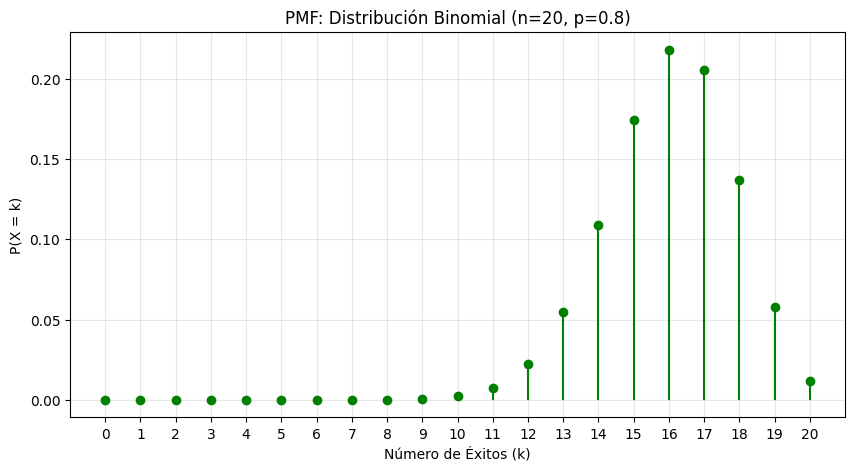

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Rango de valores para el eje x (número de éxitos)
x_binomial = np.arange(0, n + 1)

# Calcular la PMF para cada valor
pmf_binomial = dist_binomial.pmf(x_binomial)

# Visualización de la PMF
plt.figure(figsize=(10, 5))
plt.stem(x_binomial, pmf_binomial, basefmt=" ", linefmt='g-', markerfmt='go')
plt.title(f'PMF: Distribución Binomial (n={n}, p={p})')
plt.xlabel('Número de Éxitos (k)')
plt.ylabel('P(X = k)')
plt.xticks(x_binomial)
plt.grid(alpha=0.3)
plt.show()

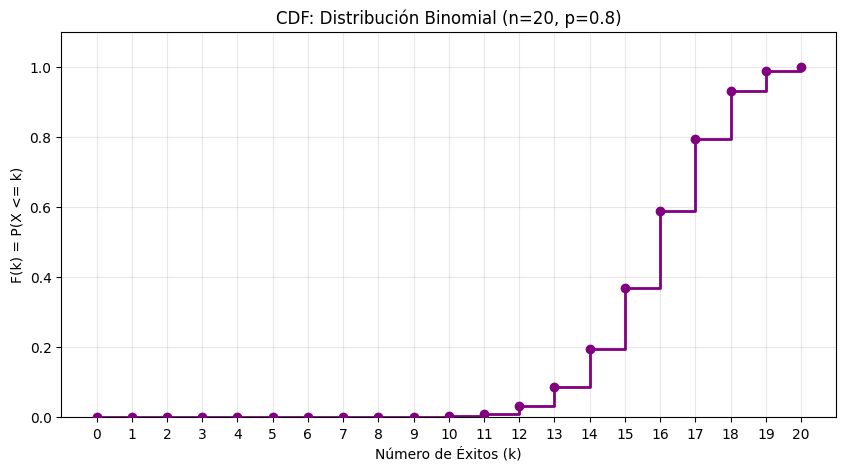

In [ ]:
# Calcular la CDF para cada valor
cdf_binomial = dist_binomial.cdf(x_binomial)

# Visualización de la CDF
plt.figure(figsize=(10, 5))
plt.step(x_binomial, cdf_binomial, where='post', color='purple', linewidth=2)
plt.scatter(x_binomial, cdf_binomial, color='purple', zorder=5)
plt.title(f'CDF: Distribución Binomial (n={n}, p={p})')
plt.xlabel('Número de Éxitos (k)')
plt.ylabel('F(k) = P(X <= k)')
plt.xticks(x_binomial)
plt.ylim(0, 1.1)
plt.grid(alpha=0.3)
plt.show()

---

#**Preguntas de Control**

---

### **1. ¿Cual es la diferencia fundamental entre una variable aleatoria discreta y una continua?**

Una variable aleatoria discreta solo puede tomar valores específicos y contables, generalmente enteros, como el número de estudiantes en un aula o el resultado de lanzar un dado. En cambio, una variable aleatoria continua puede asumir cualquier valor dentro de un intervalo determinado, incluyendo valores decimales, como la estatura, el peso o el tiempo. Además, en las variables discretas es posible calcular la probabilidad exacta de cada valor, mientras que en las continuas la probabilidad de un valor exacto es cero, por lo que se trabaja con probabilidades dentro de rangos o intervalos.

---

### **2. ¿Por qué en una variable continua $P(X = x) = 0$ para cualquier valor específico $x$?**
En una variable aleatoria continua, la probabilidad de que la variable tome exactamente un valor específico, es decir, P(X=x), es igual a cero porque una variable continua puede tomar infinitos valores posibles y por ende es imposible que tome un valor exacto.
Por esta razon para tipo de variables, la probabilidad se obtiene calculando el área bajo la función de densidad en un intervalo, por ejemplo entre dos valores, un solo valor individual no posee “ancho” o área bajo la curva de densidad, por lo que su probabilidad aislada es nula. Esto significa que su probabilidad exacta es cero porque la probabilidad solo tiene sentido en rangos de valores medibles.

---

### **3. Explique la relación entre la PMF/PDF y la CDF. ¿Cómo se obtiene una de la otra?**

La función de masa de probabilidad (PMF) en variables discretas y la función de densidad de probabilidad (PDF) en variables continuas describen cómo se distribuyen las probabilidades de una variable aleatoria, mientras que la función de distribución acumulada (CDF) representa la probabilidad de que la variable tome un valor menor o igual a un valor determinado x, es decir, F(x)=P(X≤x). La relación principal entre ellas es que la CDF se obtiene acumulando probabilidades: en una variable discreta, se calcula sumando las probabilidades de todos los valores hasta x, mientras que en una variable continua se obtiene integrando la función de densidad desde menos infinito hasta x. Por otro lado, a partir de la CDF se puede obtener la PMF calculando la diferencia entre valores consecutivos de la función acumulada, y en variables continuas se obtiene la PDF derivando la CDF respecto a x. En resumen, la PMF o PDF muestra la probabilidad puntual o densidad, mientras que la CDF muestra la probabilidad acumulada hasta un valor específico.

---


---

### **4. Una variable aleatoria $X$ representa el número de estudiantes que llegan tarde a clase. ¿Es $X$ discreta o continua? Justifique.**
Es una variable discreta porque solo puede tomar valores enteros y contables, como 0, 1, 2, 3, entre otros. No es posible que exista una cantidad fraccionaria de estudiantes, como 2.5 estudiantes tarde, ya que se trata de contar personas. Por esta razón, sus posibles resultados son específicos y separados, característica fundamental de las variables aleatorias discretas.

---

### **5. Calcule $P(X = 5)$ para una variable continua con PDF $f(x) = 2x$ en $[0,1]$. Explique su respuesta.**
Para una variable aleatoria continua con función de densidad de probabilidad f(x)=2x en el intervalo [0,1], la probabilidad de que X tome exactamente un valor específico, como X=5, es: P(X=5)=0
Esto se debe a dos razones fundamentales. Primero, el valor 5 está fuera del intervalo definido para la variable, ya que X solo puede tomar valores entre 0 y 1. Segundo, incluso si se eligiera un valor dentro del intervalo, en una variable continua la probabilidad de un valor exacto siempre es cero, porque la probabilidad se calcula como el área bajo la curva en un intervalo y un solo punto no tiene ancho ni área. Por lo tanto, la probabilidad exacta de cualquier valor específico en una distribución continua es nula.

---

### **6. Dibuje aproximadamente la CDF de una variable discreta que toma valores {1, 2, 3} con probabilidades {0.3, 0.5, 0.2}.**
La gráfica resultante es **escalonada** (steps):
*   $F(x) = 0$ para $x < 1$
*   $F(x) = 0.3$ para $1 \le x < 2$
*   $F(x) = 0.8$ para $2 \le x < 3$
*   $F(x) = 1.0$ para $x \ge 3$

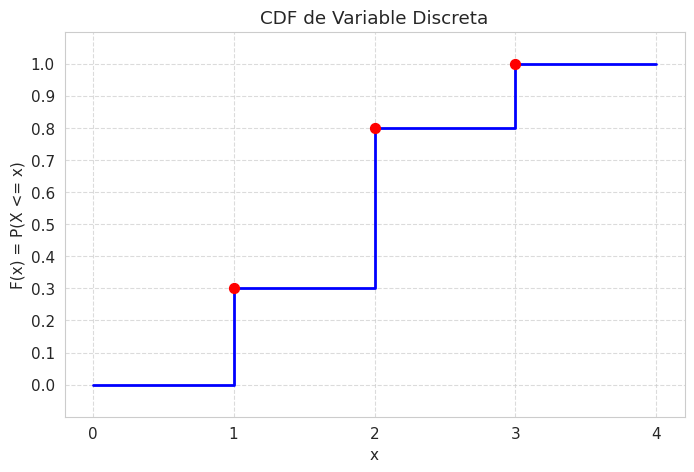

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Valores de la variable discreta
x_values = np.array([1, 2, 3])
# Probabilidades
probabilities = np.array([0.3, 0.5, 0.2])

# Calcular la CDF
cdf_values = np.cumsum(probabilities)

# Preparar los puntos para la grafica escalonada
x_plot = np.array([0, 1, 2, 3, 4])
y_plot = np.array([0, cdf_values[0], cdf_values[1], cdf_values[2], cdf_values[2]])

plt.figure(figsize=(8, 5))
plt.step(x_plot, y_plot, where='post', color='blue', linewidth=2)

# Marcar los puntos de salto
plt.scatter(x_values, cdf_values, color='red', zorder=5, s=50)

# Etiquetas y titulo
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF de Variable Discreta')
plt.xticks(np.arange(min(x_values) - 1, max(x_values) + 2))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(-0.1, 1.1)

plt.show()


---

### **7. Identifique una variable aleatoria continua en el contexto de la carrera de Computación y justifique porque es continua.**

Una variable aleatoria continua en el contexto de la carrera de Computación puede ser la cantidad de memoria RAM utilizada por un programa durante su ejecución. Esta variable es continua porque el uso de memoria puede medirse con gran precisión en diferentes unidades, como megabytes o gigabytes, incluyendo valores decimales como 256.5 MB o 1024.75 MB. Debido a que puede tomar infinitos valores dentro de un rango y no se limita únicamente a números enteros, se considera una variable continua.



---

## 📊 Conclusiones

* Se implementó con éxito la **Distribución Binomial** utilizando la librería `scipy.stats`, logrando modelar con precisión la probabilidad de éxito en sistemas tecnológicos, como la operatividad de equipos en los laboratorios de la **UNL**.

* Mediante las visualizaciones de la **PMF** y la **CDF**, se validó la naturaleza discreta de los datos, observando cómo la probabilidad se agrupa alrededor de la media según los parámetros de ensayos ($n$) y probabilidad de éxito ($p$) definidos.

* El análisis estadístico permitió concluir que modelos como la Binomial son herramientas fundamentales en la **Ingeniería en Computación** para predecir comportamientos en sistemas binarios y optimizar la toma de decisiones bajo incertidumbre.

## 💡 Recomendaciones

* Se sugiere experimentar con variaciones en el parámetro de probabilidad ($p$) para observar cómo se desplaza la campana de la distribución y cómo esto afecta la fiabilidad esperada de un sistema.
* Al trabajar con variables discretas en Python, es recomendable emplear estrictamente gráficos de tipo `stem` (para PMF) y `step` (para CDF), ya que representan correctamente los saltos finitos entre valores y evitan confusiones con distribuciones continuas.
* Para futuros proyectos de la asignatura, se propone aplicar estos modelos probabilísticos en la simulación de protocolos de red o en el análisis de fallos de hardware, integrando datos reales obtenidos en el campus de la **UNL**.

## 📚 9. Bibliografía

[1] R. E. Walpole, R. H. Myers, S. L. Myers, y K. Ye, *Probabilidad y estadística para ingeniería y ciencias*, 9na ed. Ciudad de México, México: Cengage Learning, 2016.

[2] SciPy Community, "Statistical functions (scipy.stats)," SciPy Documentation.

[3] J. Hunter, D. Dale, E. Firing, y M. Droettboom, "Matplotlib: A 2D graphics environment," Computing in Science & Engineering, vol. 9, no. 3, pp. 90-95, 2007.
